In [6]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
import sys
from pathlib import Path
import jax as jx
import time
import h5py

#ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
#coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm


sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")

import riesling as rlp



riesling_bin = Path.home() / "Documents" / "github" / "riesling" / "build" / "cxx" / "riesling"
os.environ["PATH"] += os.pathsep + str(riesling_bin)

data = '/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE/riselingwork/hires-nufft'
data_waspi = '/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE/riselingwork/raw0-waspinufft'
save_dir = "/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Paper Planning/Data"

hankel_arrays = "Hankel_matrices"

d = np.load(f"{save_dir}/inner_cache.npz")
inner_region, start, end = d['inner_region'], d['start'], d['end']

hankel_wins = (np.linspace(5,17,13))
sv_arrays = "sv_arrays"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def LORAKS_imputeals_threshold(n_iters, hankel_matrix, mask, rank, lamda, seed):


    filled_hankel = asm.softimpute_ALS_ortho(X_H = hankel_matrix, M_H = mask, rank = rank, lamda = lamda, n_iters=n_iters, seed=seed)

    return (filled_hankel)

## Build Hankel Matrices with Increasing Window Size

In [ ]:
hankel_wins = (np.linspace(5,17,13))

for win in hankel_wins:
    hankel, *_ = asm.lift(inner_region, int(win))
    np.save(f"{save_dir}/{hankel_arrays}/3dhankel_win={win}.npy", hankel)
    print(f"Hankel Matrix Saved for win = {win}")

Hankel Matrix Saved for win = 5.0
Hankel Matrix Saved for win = 6.0
Hankel Matrix Saved for win = 7.0
Hankel Matrix Saved for win = 8.0
Hankel Matrix Saved for win = 9.0
Hankel Matrix Saved for win = 10.0
Hankel Matrix Saved for win = 11.0
Hankel Matrix Saved for win = 12.0
Hankel Matrix Saved for win = 13.0
Hankel Matrix Saved for win = 14.0
Hankel Matrix Saved for win = 15.0
Hankel Matrix Saved for win = 16.0
Hankel Matrix Saved for win = 17.0


In [ ]:
inner_wid = 26
cy = cx = cz = inner_wid // 2
r = 3
yy, xx, zz = np.ogrid[:inner_wid, :inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 + (zz - cz)**2 > r**2 + 2

mask_full = np.ascontiguousarray(np.broadcast_to(mask, inner_region.shape))

for win in hankel_wins:
    masked_hankel, *_ = asm.lift(kspace=mask_full, w=int(win))
    masked_hankel = np.real(masked_hankel) > 0.5
    np.save(f"{save_dir}/{hankel_arrays}/3dmask_win={win}.npy", masked_hankel)

## Infill

In [5]:
rank = 50
lam = 5*10**-5

hankel_wins = (np.linspace(5,17,13))

for win in hankel_wins:
    hankel_matrix = np.load(f"{save_dir}/{hankel_arrays}/3dhankel_win={win}.npy")
    hankel_mask = np.load(f"{save_dir}/{hankel_arrays}/3dmask_win={win}.npy")
    thresholded_hankel = LORAKS_imputeals_threshold(n_iters=32, 
                                                            hankel_matrix= hankel_matrix, mask=hankel_mask, 
                                                            rank=rank, lamda=lam, seed=42)
    np.save(f"{save_dir}/3dhankel_thresholded_win={win}.npy", thresholded_hankel)
    del hankel_mask, thresholded_hankel


## Threshold Each and Save

In [7]:
sv_arrays = "sv_arrays"
for win in hankel_wins:
    hankel = np.load(f"{save_dir}/{hankel_arrays}/3dhankel_thresholded_win={win}.npy")
    sv = jx.numpy.linalg.svd(hankel, compute_uv=False)
    np.save(f"{save_dir}/{sv_arrays}/sv_thresholded{win}.npy", sv)
    print(f"Thresholding done for win = {win}")

Thresholding done for win = 5.0
Thresholding done for win = 6.0
Thresholding done for win = 7.0
Thresholding done for win = 8.0
Thresholding done for win = 9.0
Thresholding done for win = 10.0
Thresholding done for win = 11.0
Thresholding done for win = 12.0
Thresholding done for win = 13.0
Thresholding done for win = 14.0
Thresholding done for win = 15.0
Thresholding done for win = 16.0
Thresholding done for win = 17.0


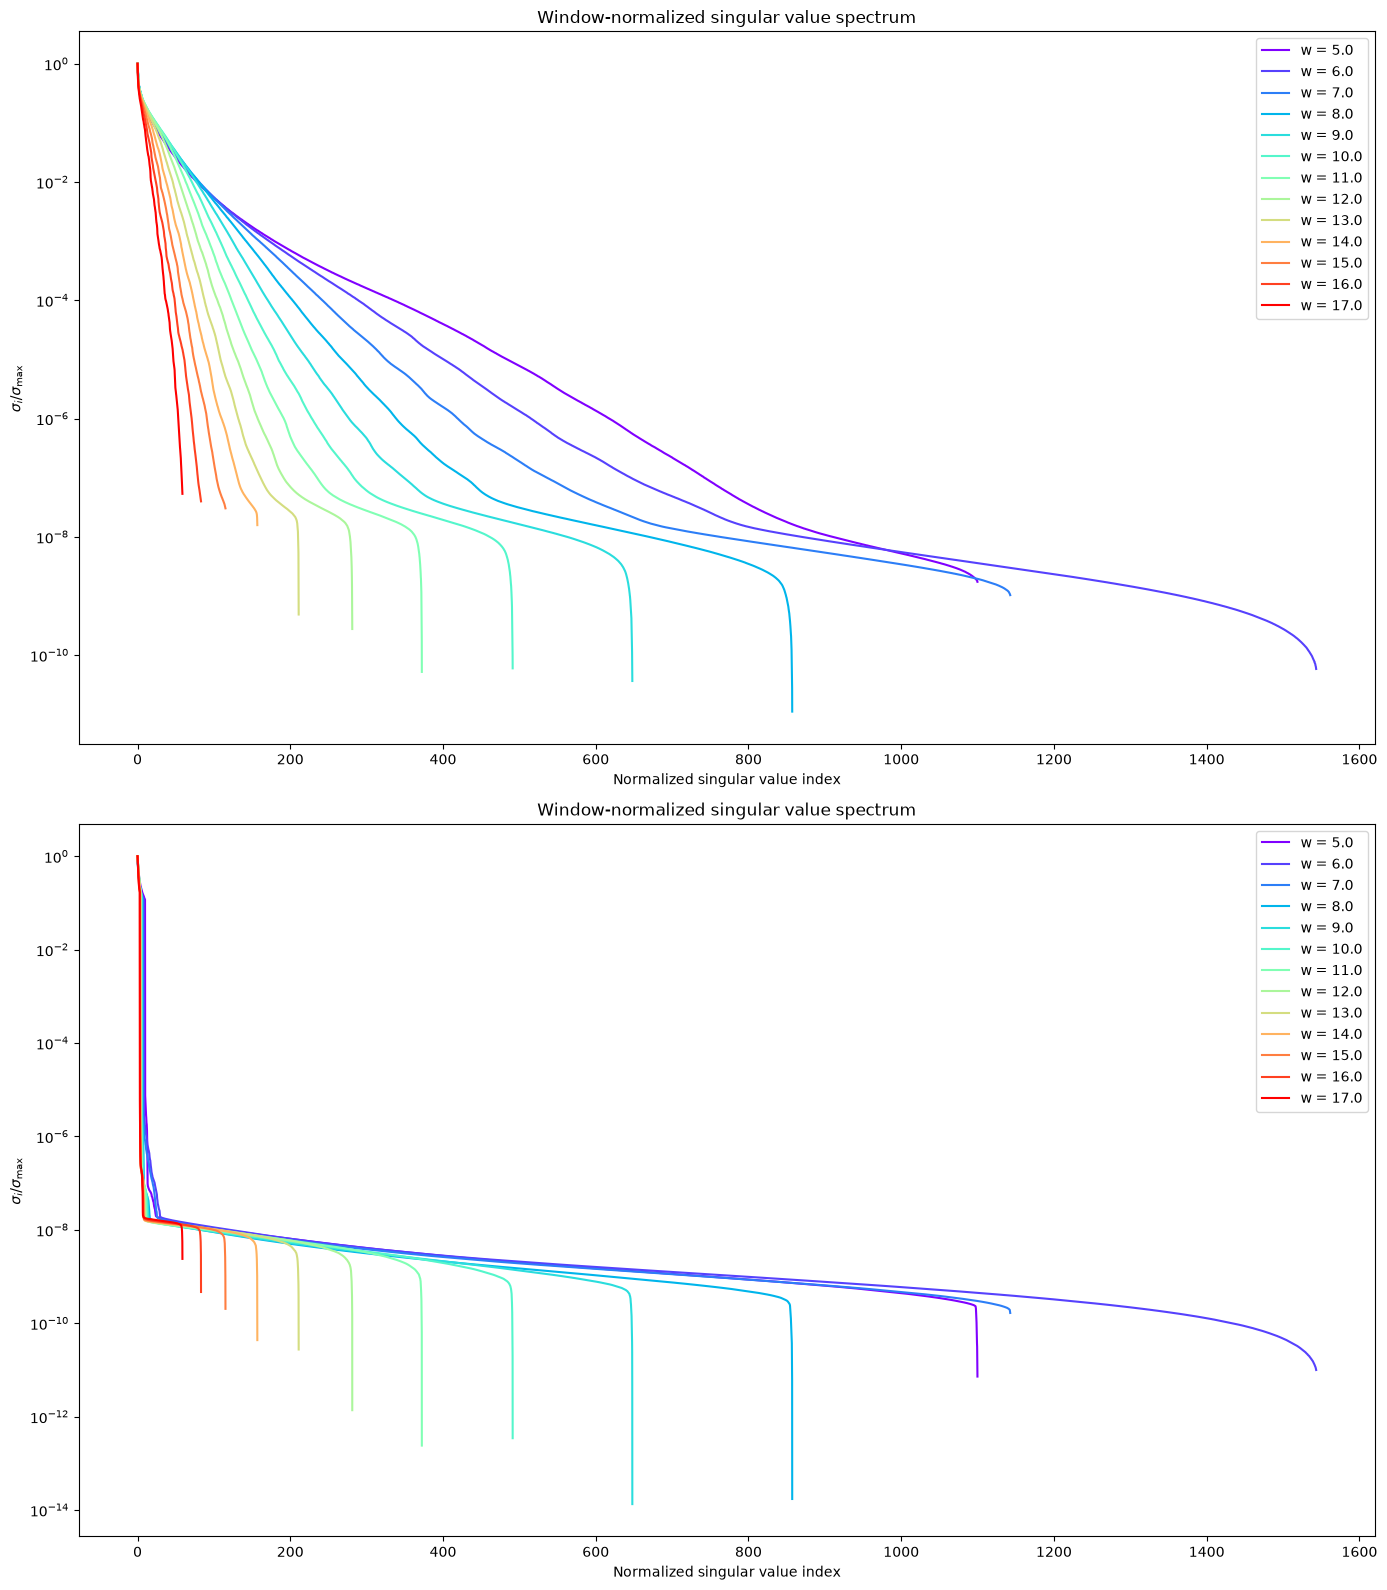

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 16))
colors = plt.cm.rainbow(np.linspace(0, 1, len(hankel_wins)))


ax = axes[0]
for win, c in zip(hankel_wins, colors):
    sv = np.load(f"{save_dir}/{sv_arrays}/sv_{win}.npy")
    x = np.arange(len(sv)) / (win)
    ax.plot(x, sv / sv[0], color=c, label=f"w = {win}")

ax.set_yscale("log")
ax.set_xlabel("Normalized singular value index")
ax.set_ylabel(r"$\sigma_i / \sigma_{\max}$")
ax.set_title("Window-normalized singular value spectrum")
ax.legend()


ax = axes[1]
for win, c in zip(hankel_wins, colors):
    sv = np.load(f"{save_dir}/{sv_arrays}/sv_thresholded{win}.npy")
    x = np.arange(len(sv)) / (win)
    ax.plot(x, sv / sv[0], color=c, label=f"w = {win}")

ax.set_yscale("log")
ax.set_xlabel("Normalized singular value index")
ax.set_ylabel(r"$\sigma_i / \sigma_{\max}$")
ax.set_title("Window-normalized singular value spectrum")
ax.legend()
fig.savefig('sv_spectra.pdf')
plt.tight_layout()
plt.show()